In [25]:
import csv

f = open('C:/Users/Admin/projects/myproject/card (1).csv', encoding='utf-8')
data = csv.reader(f)

header = next(data)

s_mon = [0, 0, 0]
spend = 0

for row in data:
    if row[8].strip() == '전표매입':
        mon = int(row[0].split('-')[1])
        payment = int(row[6].replace(',', '').strip())

        idx = mon - 10
        s_mon[idx] += payment
        spend += payment

print("월별 합계:", s_mon)
print("총 지출:", spend)

월별 합계: [2093015, 4127744, 1953269]
총 지출: 8174028


In [34]:
import csv

f = open('C:/Users/Admin/projects/myproject/card (1).csv', encoding='utf-8')
data = csv.reader(f)

header = next(data)
taxi = [0,0,0]

for row in data:
    status = row[8].strip()
    store = row[5]
    
    if status == '전표매입' and '택시' in store:
        month = int(row[0].split('-')[1])
        payment = int(row[6].replace(',', '').strip())
        
        if 10 <= month <= 12:
            taxi[month-10] += payment

print(taxi)

[8600, 83900, 52800]


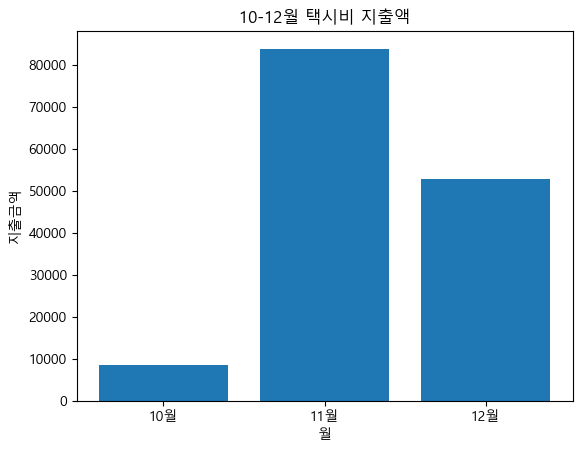

In [56]:
plt.rcParams['font.family'] = 'Malgun Gothic'

months = ['10월', '11월', '12월']

plt.figure()
plt.bar(months, taxi)

plt.title('10-12월 택시비 지출액')
plt.xlabel('월')
plt.ylabel('지출금액')

plt.show()

In [51]:
import csv

f = open('C:/Users/Admin/projects/myproject/card (1).csv', encoding='utf-8')
data = csv.reader(f)

header = next(data)
deli = [0, 0, 0]

for row in data:
    status = row[8].strip()
    store = row[5]

    if row[-1] == '전표매입' and row[5] == '(주)우아한형제들':
        mon,payment = int(row[0].split('-')[1]),int(row[-3])
        idx = mon -10
        deli[idx] += payment

print(deli)

[134300, 127900, 99230]


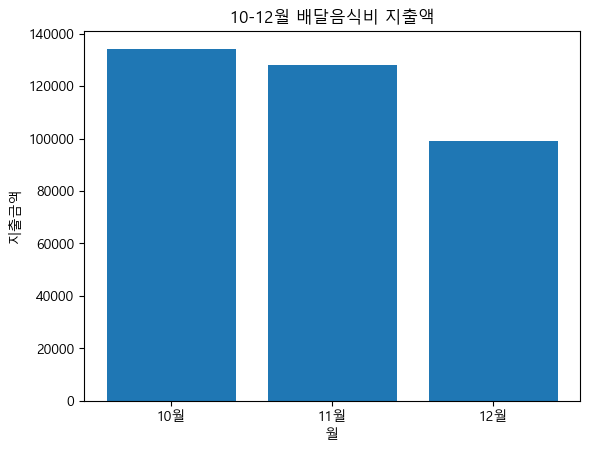

In [52]:
plt.rcParams['font.family'] = 'Malgun Gothic'

months = ['10월', '11월', '12월']

plt.bar(months, deli)
plt.title('10-12월 배달음식비 지출액')
plt.xlabel('월')
plt.ylabel('지출금액')

plt.show()

In [42]:
import matplotlib.pyplot as plt

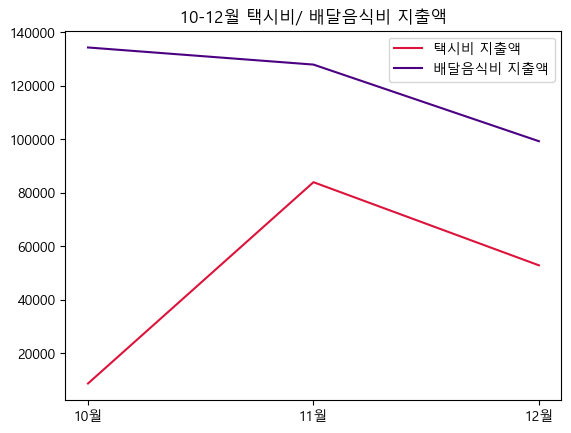

In [49]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title('10-12월 택시비/ 배달음식비 지출액')
plt.plot(['10월', '11월', '12월'], taxi, color = 'crimson', label = '택시비 지출액')
plt.plot(['10월', '11월', '12월'], deli, color = 'indigo', label = '배달음식비 지출액')
plt.legend()
plt.show()

In [62]:
#지출액 상위 10개 항목 뽑기
import csv
import operator

f = open('C:/Users/Admin/projects/myproject/card (1).csv', encoding='utf-8-sig')
data = csv.reader(f)
header = next(data)

spending = {}

for row in data:
    if row[8].strip() == '전표매입':
        store = row[5]
        payment = int(row[6].replace(',', '').strip())

        if store not in spending:
            spending[store] = payment
        else:
            spending[store] += payment

f.close()
sorted_spending = sorted(spending.items(), key=operator.itemgetter(1), reverse=True)
top10 = sorted_spending[:10]

for store, amount in top10:
    print(store, f"{amount:,}")

네이버파이낸셜(주) 1,395,840
스마일페이 (신라면세점) 978,035
(주)현대백화점신촌점 415,502
네이버페이 374,976
(주)우아한형제들 361,430
(주)신세계백화점강남점 333,800
(주)이마트  신촌점 305,690
크로키닷컴 299,610
이유 285,000
쿠팡 273,790


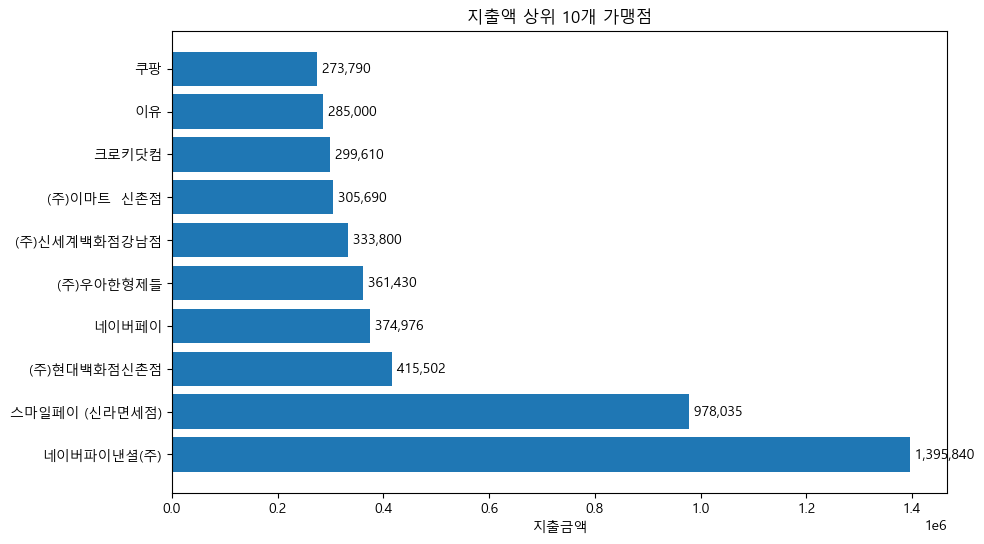

In [70]:
import matplotlib.pyplot as plt

# top10에서 가맹점명 / 금액 분리
stores = [x[0] for x in top10]
amounts = [x[1] for x in top10]

# 한글 폰트 (윈도우)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,6))
plt.barh(stores, amounts)

plt.title('지출액 상위 10개 가맹점')
plt.xlabel('지출금액')

# 금액 표시
for i, v in enumerate(amounts):
    plt.text(v, i, f' {v:,}', va='center')

plt.show()